# Phase 2 — Fine-tuning `SentimentLabel`




# 04 - LLM : Tokenisation (XLM-R) + Fine-tuning XLM-RoBERTa

On part des splits `Train` / `Validation` / `Test` produits par le notebook 03
(`comptes_rendus_train.csv`, `comptes_rendus_validation.csv`, `comptes_rendus_test.csv`).

## Objectif de ce notebook

Entraîner **deux têtes de classification séparées** sur `xlm-roberta-base`, avec Hugging Face `Trainer` :

1. **Modèle Sentiment** : classification 3 classes (`Positif` / `Neutre` / `Négatif`), entraîné sur
   l'ensemble du corpus.
2. **Modèle Churn** : classification du `ChurnRisk`, entraîné **uniquement sur les enregistrements
   `SentimentLabel == "Négatif"`** (cf. section 3.5 du notebook 03), puisque le risque de churn n'a de
   sens à évaluer que sur les clients mécontents.

## Pipeline

```
Texte client -> Tokenisation (XLM-R) -> Input IDs + Attention Mask -> XLM-RoBERTa
             -> Classification Head -> Sentiment
                                     -> (si Négatif) -> ChurnRisk
```


In [5]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00


In [6]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Split
from sklearn.model_selection import train_test_split

# Métriques
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

# Hugging Face
from datasets import Dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

import evaluate
import torch
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


## Configuration

In [7]:
CONFIG = {
    # chemin du corpus labellisé produit en Phase 1 — adapte selon ton environnement
    # (ex: "/content/data_prete_labeled.csv" si tu uploades directement sur Colab,
    # ou "/content/drive/MyDrive/.../data_prete_labeled.csv" si tu passes par Drive)
    "DATA_PATH": r"data_prete_labeled.csv",

    "TEXT_COL": "clean_text_v2",     # même colonne que celle utilisée pour générer le silver en Phase 1
    "LANG_COL": "langue",
    "LABEL_COL": "SentimentLabel",

    # Modèle multilingue de départ pour le fine-tuning (couvre français + arabe ;
    # l'arabizi est géré via le tokenizer SentencePiece de XLM-R, moins bien qu'un modèle
    # spécifiquement tunisien comme TunBERT — à tester en alternative si les résultats
    # sur l'arabizi sont décevants).
    "MODEL_NAME": "xlm-roberta-base",

    "MAX_LENGTH": 128,
    "TRAIN_FRAC": 0.70,
    "VAL_FRAC": 0.15,
    "TEST_FRAC": 0.15,
    "SEED": 42,

    "OUTPUT_DIR": "./sentiment_xlmr",
    "BATCH_SIZE": 16,
    "NUM_EPOCHS": 6,
    "LEARNING_RATE": 2e-5,
}


## 1 — Chargement des données

On charge directement le corpus déjà labellisé (`SentimentLabel`, `ChurnRisk`) en phase 1

In [8]:
from google.colab import files
uploaded = files.upload()  # sélectionne data_prete_labeled.csv
CONFIG["DATA_PATH"] = list(uploaded.keys())[0]


Saving data_prete_labeled.csv to data_prete_labeled.csv


In [9]:
df = pd.read_csv(CONFIG["DATA_PATH"])
print("Shape :", df.shape)

assert CONFIG["LABEL_COL"] in df.columns, f"{CONFIG['LABEL_COL']} absent — as-tu bien uploadé data_prete_labeled.csv (sortie de la Phase 1) ?"
assert CONFIG["TEXT_COL"] in df.columns, f"{CONFIG['TEXT_COL']} absent du corpus."

n_missing_label = df[CONFIG["LABEL_COL"]].isna().sum()
n_missing_text = df[CONFIG["TEXT_COL"]].isna().sum()
print(f"Lignes avec {CONFIG['LABEL_COL']} manquant :", n_missing_label)
print(f"Lignes avec {CONFIG['TEXT_COL']} manquant :", n_missing_text)

df = df.dropna(subset=[CONFIG["LABEL_COL"], CONFIG["TEXT_COL"]]).reset_index(drop=True)
print("Shape après nettoyage :", df.shape)

df[CONFIG["LABEL_COL"]].value_counts()


Shape : (4740, 40)
Lignes avec SentimentLabel manquant : 0
Lignes avec clean_text_v2 manquant : 0
Shape après nettoyage : (4740, 40)


,count
SentimentLabel,
Neutre,2112
Négatif,1328
Positif,1300


## 2 — Vérification du biais langue × sentiment



SentimentLabel  Neutre  Négatif  Positif
langue                                  
arabe              955      584      403
arabizi            592      200      443
français           565      544      454

En % par langue :
SentimentLabel  Neutre  Négatif  Positif
langue                                  
arabe             49.2     30.1     20.8
arabizi           47.9     16.2     35.9
français          36.1     34.8     29.0

Toutes les combinaisons langue x sentiment sont représentées — pas de cellule vide.


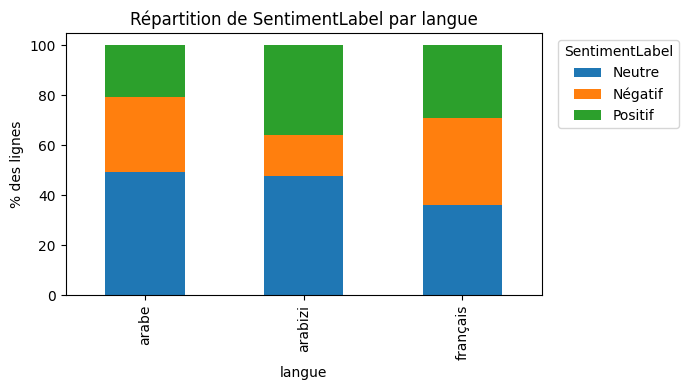

In [10]:
crosstab = pd.crosstab(df[CONFIG["LANG_COL"]], df[CONFIG["LABEL_COL"]])
print(crosstab)

crosstab_pct = pd.crosstab(df[CONFIG["LANG_COL"]], df[CONFIG["LABEL_COL"]], normalize="index") * 100
print("\nEn % par langue :")
print(crosstab_pct.round(1))

if (crosstab == 0).any().any():
    print("\n Au moins une combinaison langue x sentiment est totalement absente — biais potentiel, à documenter.")
else:
    print("\nToutes les combinaisons langue x sentiment sont représentées — pas de cellule vide.")

crosstab_pct.plot(kind="bar", stacked=True, figsize=(7, 4))
plt.ylabel("% des lignes")
plt.title("Répartition de SentimentLabel par langue")
plt.legend(title="SentimentLabel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 3 — Encodage des labels et split stratifié train / val / test (par template)

Le split est fait au niveau du **template** (`template_id`, créé en Phase 1) et pas au niveau de la ligne : toutes les lignes issues d'un même template restent ensemble dans un seul sous-ensemble (train, val ou test), pour éviter que le modèle "reconnaisse" un texte vu à l'entraînement plutôt que d'apprendre à généraliser. La stratification `langue × SentimentLabel` est appliquée au niveau des templates.

In [ ]:
assert "template_id" in df.columns, "template_id absent — vérifie que tu utilises bien data_prete_labeled.csv (sortie Phase 1)."

labels_uniques = sorted(df[CONFIG["LABEL_COL"]].unique())
label2id = {label: i for i, label in enumerate(labels_uniques)}
id2label = {i: label for label, i in label2id.items()}
print("label2id :", label2id)

df["label"] = df[CONFIG["LABEL_COL"]].map(label2id)

# --- Regroupement au niveau du TEMPLATE (pas de la ligne) pour éviter la fuite de données ---
# On résume chaque template par sa langue et son label dominants
template_info = (
    df.groupby("template_id")
      .agg({CONFIG["LANG_COL"]: "first", CONFIG["LABEL_COL"]: "first"})
      .reset_index()
)
template_info["strate"] = (
    template_info[CONFIG["LANG_COL"]].astype(str) + "__" + template_info[CONFIG["LABEL_COL"]].astype(str)
)

def fusionner_strates_rares(info_df, seuil=2):
    """Fusionne les strates avec moins de `seuil` templates pour éviter les erreurs de stratification."""
    effectifs = info_df["strate"].value_counts()
    rares = effectifs[effectifs < seuil].index
    if len(rares) > 0:
        print(f" {len(rares)} strate(s) < {seuil} templates, fusionnées :", list(rares))
        info_df.loc[info_df["strate"].isin(rares), "strate"] = "autre__autre"
    return info_df

template_info = fusionner_strates_rares(template_info)


In [ ]:
# Split des TEMPLATES (pas des lignes) — 70/15/15
train_tpl, temp_tpl = train_test_split(
    template_info,
    test_size=(1 - CONFIG["TRAIN_FRAC"]),
    stratify=template_info["strate"],
    random_state=CONFIG["SEED"],
)

# Sécurité : on refusionne les strates devenues trop petites AVANT le 2e split
# (une strate à 3 templates peut tomber à 1 seul dans temp_tpl après le 1er split,
# ce qui ferait planter le split stratifié suivant)
temp_tpl = fusionner_strates_rares(temp_tpl.copy())

val_ratio_of_temp = CONFIG["VAL_FRAC"] / (CONFIG["VAL_FRAC"] + CONFIG["TEST_FRAC"])
val_tpl, test_tpl = train_test_split(
    temp_tpl,
    test_size=(1 - val_ratio_of_temp),
    stratify=temp_tpl["strate"],
    random_state=CONFIG["SEED"],
)

# On applique le split de templates aux LIGNES du corpus
train_df = df[df["template_id"].isin(train_tpl["template_id"])].reset_index(drop=True)
val_df   = df[df["template_id"].isin(val_tpl["template_id"])].reset_index(drop=True)
test_df  = df[df["template_id"].isin(test_tpl["template_id"])].reset_index(drop=True)

print(f"Train : {len(train_df)} lignes ({train_df['template_id'].nunique()} templates)")
print(f"Val   : {len(val_df)} lignes ({val_df['template_id'].nunique()} templates)")
print(f"Test  : {len(test_df)} lignes ({test_df['template_id'].nunique()} templates)")

for nom, sous_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n--- {nom} — répartition {CONFIG['LABEL_COL']} ---")
    print(sous_df[CONFIG["LABEL_COL"]].value_counts(normalize=True).round(3))


## 5 — Tokenisation

In [13]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["MODEL_NAME"])

def to_hf_dataset(sous_df):
    return Dataset.from_pandas(
        sous_df[[CONFIG["TEXT_COL"], "label"]].rename(columns={CONFIG["TEXT_COL"]: "text"}),
        preserve_index=False,
    )

raw_datasets = DatasetDict({
    "train": to_hf_dataset(train_df),
    "validation": to_hf_dataset(val_df),
    "test": to_hf_dataset(test_df),
})

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=CONFIG["MAX_LENGTH"],
    )

tokenized_datasets = raw_datasets.map(tokenize_fn, batched=True)
tokenized_datasets


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/3317 [00:00<?, ? examples/s]

Map:   0%|          | 0/711 [00:00<?, ? examples/s]

Map:   0%|          | 0/712 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 3317
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 711
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 712
    })
})

## 6 — Modèle et métriques

`class_weights` compense un éventuel déséquilibre entre classes dans la loss 

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from collections import Counter

counts = Counter(train_df["label"])
n_total = sum(counts.values())
n_classes = len(label2id)

# Sécurité : une classe absente du train set ferait planter le calcul des poids (division par zéro)
for i in range(n_classes):
    if counts[i] == 0:
        raise ValueError(f"La classe '{id2label[i]}' n'a aucun exemple dans train_df — le split pose problème.")

class_weights = torch.tensor(
    [n_total / (n_classes * counts[i]) for i in range(n_classes)],
    dtype=torch.float,
).to(device)
print("Poids par classe :", {id2label[i]: round(w.item(), 3) for i, w in enumerate(class_weights)})

model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["MODEL_NAME"],
    num_labels=n_classes,
    id2label=id2label,
    label2id=label2id,
).to(device)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "f1_macro": f1,
        "precision_macro": precision,
        "recall_macro": recall,
    }

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


## 7 — Entraînement

In [16]:
training_args = TrainingArguments(
    output_dir=CONFIG["OUTPUT_DIR"],
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=CONFIG["LEARNING_RATE"],
    per_device_train_batch_size=CONFIG["BATCH_SIZE"],
    per_device_eval_batch_size=CONFIG["BATCH_SIZE"],
    num_train_epochs=CONFIG["NUM_EPOCHS"],
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=CONFIG["SEED"],
    fp16=torch.cuda.is_available(),
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.347617,0.343848,0.895921,0.897516,0.893680,0.902287
2,0.291150,0.306384,0.939522,0.939191,0.942549,0.936199
3,0.294143,0.292628,0.939522,0.939788,0.945766,0.934953
4,0.189562,0.304214,0.935302,0.935316,0.935044,0.935641
5,0.190452,0.315279,0.925457,0.926285,0.928776,0.924455


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1040, training_loss=0.293918899847911, metrics={'train_runtime': 331.1947, 'train_samples_per_second': 60.092, 'train_steps_per_second': 3.768, 'total_flos': 1090934008254720.0, 'train_loss': 0.293918899847911, 'epoch': 5.0})

## 8 — Évaluation sur le test set



Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision Macro,Recall Macro
0.190452,0.240507,5,0.942416,0.943439,0.945751,0.941665


{'eval_loss': 0.240507110953331, 'eval_accuracy': 0.9424157303370787, 'eval_f1_macro': 0.9434387893666933, 'eval_precision_macro': 0.9457508811309981, 'eval_recall_macro': 0.9416648295835225}



               precision    recall  f1-score   support

      Neutre       0.93      0.95      0.94       318
     Négatif       0.98      0.93      0.95       200
     Positif       0.93      0.95      0.94       194

    accuracy                           0.94       712
   macro avg       0.95      0.94      0.94       712
weighted avg       0.94      0.94      0.94       712



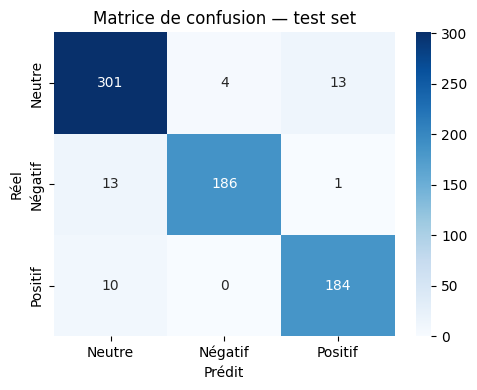

In [17]:
test_results = trainer.evaluate(tokenized_datasets["test"])
print(test_results)

predictions = trainer.predict(tokenized_datasets["test"])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

print("\n", classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(n_classes)]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[id2label[i] for i in range(n_classes)],
            yticklabels=[id2label[i] for i in range(n_classes)])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion — test set")
plt.tight_layout()
plt.show()


## 9 — Analyse par langue
On revérifie ici que le modèle ne se contente pas d'exploiter la langue comme raccourci : les performances doivent rester comparables entre `français`, `arabe` et `arabizi`.

In [18]:
test_df_eval = test_df.copy().reset_index(drop=True)
test_df_eval["y_true"] = y_true
test_df_eval["y_pred"] = y_pred

for langue in test_df_eval[CONFIG["LANG_COL"]].unique():
    sous = test_df_eval[test_df_eval[CONFIG["LANG_COL"]] == langue]
    acc = accuracy_score(sous["y_true"], sous["y_pred"])
    print(f"{langue:10s} — n={len(sous):4d} — accuracy={acc:.3f}")


arabe      — n= 292 — accuracy=0.911
français   — n= 235 — accuracy=0.983
arabizi    — n= 185 — accuracy=0.941


## 10 — Comparaison avec LoRA

In [23]:
!pip install -q -U peft torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 41.1 MB/s eta 0:00:00


In [24]:
from peft import LoraConfig, get_peft_model, TaskType

# Modèle de base ré-instancié "propre" (celui de la section 6 a déjà été fine-tuné en entier,
# on ne veut pas repartir de ces poids-là pour une comparaison équitable).
base_model_lora = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["MODEL_NAME"],
    num_labels=n_classes,
    id2label=id2label,
    label2id=label2id,
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                    # rang des matrices LoRA
    lora_alpha=16,           # facteur d'échelle (règle courante : alpha = 2*r)
    lora_dropout=0.1,
    target_modules=["query", "value"],  # couches d'attention de XLM-R
)

lora_model = get_peft_model(base_model_lora, lora_config).to(device)
lora_model.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 887,811 || all params: 278,933,766 || trainable%: 0.3183


In [25]:
# LoRA bénéficie généralement d'un learning rate plus élevé que le fine-tuning complet,
# puisqu'on entraîne beaucoup moins de paramètres.
lora_training_args = TrainingArguments(
    output_dir="./sentiment_xlmr_lora",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=CONFIG["BATCH_SIZE"],
    per_device_eval_batch_size=CONFIG["BATCH_SIZE"],
    num_train_epochs=CONFIG["NUM_EPOCHS"],
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=CONFIG["SEED"],
    fp16=torch.cuda.is_available(),
)

lora_trainer = WeightedTrainer(
    model=lora_model,
    args=lora_training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

lora_trainer.train()


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.476316,0.367221,0.883263,0.885194,0.880823,0.891611
2,0.364617,0.305514,0.912799,0.913390,0.911338,0.916255
3,0.299353,0.279822,0.909986,0.911129,0.905924,0.918644
4,0.281082,0.311699,0.914205,0.915205,0.910546,0.921799
5,0.246177,0.317052,0.911392,0.912453,0.907774,0.919064
6,0.206605,0.308195,0.915612,0.916788,0.912359,0.922868


TrainOutput(global_step=1248, training_loss=0.3690870870382358, metrics={'train_runtime': 115.2292, 'train_samples_per_second': 172.717, 'train_steps_per_second': 10.831, 'total_flos': 1322690766658560.0, 'train_loss': 0.3690870870382358, 'epoch': 6.0})

In [26]:
lora_test_results = lora_trainer.evaluate(tokenized_datasets["test"])
print(lora_test_results)

lora_predictions = lora_trainer.predict(tokenized_datasets["test"])
lora_y_pred = np.argmax(lora_predictions.predictions, axis=-1)
lora_y_true = lora_predictions.label_ids

print("\n", classification_report(lora_y_true, lora_y_pred, target_names=[id2label[i] for i in range(n_classes)]))

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision Macro,Recall Macro
0.206605,0.264355,6,0.924157,0.925551,0.923233,0.928708


{'eval_loss': 0.26435530185699463, 'eval_accuracy': 0.9241573033707865, 'eval_f1_macro': 0.925551293996575, 'eval_precision_macro': 0.92323347504323, 'eval_recall_macro': 0.9287079902310403}



               precision    recall  f1-score   support

      Neutre       0.93      0.90      0.92       318
     Négatif       0.94      0.93      0.94       200
     Positif       0.89      0.95      0.92       194

    accuracy                           0.92       712
   macro avg       0.92      0.93      0.93       712
weighted avg       0.92      0.92      0.92       712



### Comparaison fine-tuning complet vs LoRA


In [27]:
n_params_total = sum(p.numel() for p in base_model_lora.parameters())
n_params_trainable_lora = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
n_params_trainable_full = sum(p.numel() for p in model.parameters() if p.requires_grad)

comparaison = pd.DataFrame([
    {
        "méthode": "Fine-tuning complet",
        "params entraînés": n_params_trainable_full,
        "% des params": 100.0,
        "accuracy test": test_results["eval_accuracy"],
        "f1_macro test": test_results["eval_f1_macro"],
    },
    {
        "méthode": "LoRA (r=8)",
        "params entraînés": n_params_trainable_lora,
        "% des params": round(100 * n_params_trainable_lora / n_params_total, 3),
        "accuracy test": lora_test_results["eval_accuracy"],
        "f1_macro test": lora_test_results["eval_f1_macro"],
    },
])
comparaison

,méthode,params entraînés,% des params,accuracy test,f1_macro test
0,Fine-tuning complet,278045955,100.000,0.942416,0.943439
1,LoRA (r=8),887811,0.318,0.924157,0.925551


## 11 — Sauvegarde du modèle

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
trainer.save_model(CONFIG["OUTPUT_DIR"])
tokenizer.save_pretrained(CONFIG["OUTPUT_DIR"])

import shutil
shutil.make_archive("sentiment_xlmr_model", "zip", CONFIG["OUTPUT_DIR"])

# Copie directe sur Drive au lieu du téléchargement navigateur
shutil.copy("sentiment_xlmr_model.zip", "/content/drive/MyDrive/sentiment_xlmr_model.zip")
print("Copié sur Drive : /content/drive/MyDrive/sentiment_xlmr_model.zip")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Copié sur Drive : /content/drive/MyDrive/sentiment_xlmr_model.zip
